In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Seminar/augmenting_nlms_meco"

anm	 DataPreparation.ipynb	LICENSE   output     requirements.txt
configs  GECO_data_prep.py	notebook  README.md  scripts


In [ ]:
!cp -r "/content/drive/MyDrive/Seminar/augmenting_nlms_meco" /content/

#DEBUGGING

In [ ]:
%cd /content/augmenting_nlms_meco

/content/augmenting_nlms_meco


In [ ]:
!ls

anm			   DataPreparation.ipynb  notebook   requirements.txt
augmenting_nlms_meco_data  GECO_data_prep.py	  output     scripts
configs			   LICENSE		  README.md


In [ ]:
!find augmenting_nlms_meco_data -maxdepth 2 -type f | head -20

augmenting_nlms_meco_data/.gitignore
augmenting_nlms_meco_data/geco/pp23_dataset_test.csv
augmenting_nlms_meco_data/geco/pp29_dataset.csv
augmenting_nlms_meco_data/geco/pp26_dataset.csv
augmenting_nlms_meco_data/geco/pp27_dataset.csv
augmenting_nlms_meco_data/geco/pp29_dataset_test.csv
augmenting_nlms_meco_data/geco/pp26_dataset_test.csv
augmenting_nlms_meco_data/geco/pp27_dataset_test.csv
augmenting_nlms_meco_data/geco/pp31_dataset_test.csv
augmenting_nlms_meco_data/geco/pp31_dataset.csv
augmenting_nlms_meco_data/geco/pp23_dataset.csv
augmenting_nlms_meco_data/README.md
augmenting_nlms_meco_data/.git
augmenting_nlms_meco_data/en/en_49_dataset.csv
augmenting_nlms_meco_data/en/en_6_dataset.csv
augmenting_nlms_meco_data/en/en_98_dataset.csv
augmenting_nlms_meco_data/en/all_mean_dataset.csv
augmenting_nlms_meco_data/en/en_83_dataset.csv
augmenting_nlms_meco_data/en/en_57_dataset.csv
augmenting_nlms_meco_data/complexity_data/complexity_ds_en.csv


In [ ]:
!pwd
!ls -la

/content/augmenting_nlms_meco
total 136
drwx------ 9 root root  4096 Sep 24 15:51 .
drwxr-xr-x 1 root root  4096 Sep 24 15:51 ..
drwx------ 7 root root  4096 Sep 24 15:51 anm
drwxr-xr-x 7 root root  4096 Sep 24 15:51 augmenting_nlms_meco_data
drwx------ 2 root root  4096 Sep 24 15:51 configs
-rw------- 1 root root 72375 Sep 24 16:03 DataPreparation.ipynb
-rw------- 1 root root  4514 Sep 24 16:03 GECO_data_prep.py
drwx------ 8 root root  4096 Sep 24 15:51 .git
-rw------- 1 root root  3139 Sep 24 16:03 .gitignore
-rw------- 1 root root   419 Sep 24 16:03 .gitmodules
-rw------- 1 root root  1068 Sep 24 16:03 LICENSE
drwx------ 2 root root  4096 Sep 24 15:51 notebook
drwx------ 2 root root  4096 Sep 24 15:51 output
-rw------- 1 root root    22 Sep 24 16:03 README.md
-rw------- 1 root root   118 Sep 24 16:03 requirements.txt
drwx------ 2 root root  4096 Sep 24 15:51 scripts


In [ ]:
!cat .gitmodules

[submodule "augmenting_nlms_meco_data"]
	path = augmenting_nlms_meco_data
	url = git@github.com:Andrew-Wyn/augmenting_nlms_meco_data.git
[submodule "attn_correlation/modules/ValueZeroing"]
	path = anm/attn_correlation/modules/ValueZeroing
	url = git@github.com:lucadinidue/ValueZeroing.git
[submodule "attn_correlation/modules/alti"]
	path = anm/attn_correlation/modules/alti
	url = git@github.com:lucadinidue/alti.git


In [ ]:
!sed -i 's|git@github.com:Andrew-Wyn/augmenting_nlms_meco_data.git|https://github.com/Andrew-Wyn/augmenting_nlms_meco_data.git|' .gitmodules
!sed -i 's|git@github.com:lucadinidue/ValueZeroing.git|https://github.com/lucadinidue/ValueZeroing.git|' .gitmodules
!sed -i 's|git@github.com:lucadinidue/alti.git|https://github.com/lucadinidue/alti.git|' .gitmodules

!cat .gitmodules

[submodule "augmenting_nlms_meco_data"]
	path = augmenting_nlms_meco_data
	url = https://github.com/Andrew-Wyn/augmenting_nlms_meco_data.git
[submodule "attn_correlation/modules/ValueZeroing"]
	path = anm/attn_correlation/modules/ValueZeroing
	url = https://github.com/lucadinidue/ValueZeroing.git
[submodule "attn_correlation/modules/alti"]
	path = anm/attn_correlation/modules/alti
	url = https://github.com/lucadinidue/alti.git


In [ ]:
!git submodule sync --recursive
!git submodule update --init --recursive

Submodule 'attn_correlation/modules/ValueZeroing' (https://github.com/lucadinidue/ValueZeroing.git) registered for path 'anm/attn_correlation/modules/ValueZeroing'
Submodule 'attn_correlation/modules/alti' (https://github.com/lucadinidue/alti.git) registered for path 'anm/attn_correlation/modules/alti'
Submodule 'augmenting_nlms_meco_data' (https://github.com/Andrew-Wyn/augmenting_nlms_meco_data.git) registered for path 'augmenting_nlms_meco_data'
Submodule path 'anm/attn_correlation/modules/ValueZeroing': checked out '57d448daf9541e88062883f8374341566e4c06ee'


In [ ]:
!echo "=== DATA ==="
!ls augmenting_nlms_meco_data | head

!echo "=== VALUE ZEROING ==="
!ls anm/attn_correlation/modules/ValueZeroing | head

!echo "=== ALTI ==="
!ls anm/attn_correlation/modules/alti | head

=== DATA ===
complexity_data
en
geco
it
joint_data_trimmed.csv
README.md
sentiment
=== VALUE ZEROING ===
data
demo.py
finetuning
modeling
probing
README.md
requirements.txt
scoring
utils
=== ALTI ===
attributions.py
attributions.sh
aupc.py
correlations.py
cos_results
data
environment.yml
evaluation.ipynb
finetuning
finetuning.sh


In [ ]:
!pip install -r requirements.txt

In [ ]:
!grep -v "neuralcoref" anm/attn_correlation/modules/ValueZeroing/requirements.txt > /tmp/vz_requirements.txt
!cat /tmp/vz_requirements.txt
!pip install -r /tmp/vz_requirements.txt

transformers==4.15.0
  Using cached transformers-4.15.0-py3-none-any.whl.metadata (59 kB)
  Using cached sacremoses-0.2.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached tokenizers-0.10.3.tar.gz (212 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.15.0-py3-none-any.whl (3.4 MB)
Using cached sacremoses-0.2.0-py3-none-any.whl (867 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [ ]:
!cat requirements.txt

numpy
pandas
scikit-learn
matplotlib
scipy
tqdm
keras
transformers
torch
tensorflow
datasets
accelerate
seaborn
scipy


In [ ]:
import sys
import torch
import transformers

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
Transformers: 4.57.6


In [ ]:
!grep -R "import neuralcoref\|from neuralcoref" -n \
    anm scripts 2>/dev/null

anm/attn_correlation/modules/ValueZeroing/data/blimp_postprocessing.py:4:import neuralcoref


In [ ]:
!grep -R "ValueZeroing\|valuezero" -n \
    anm scripts 2>/dev/null | head -50

anm/attn_correlation/utils.py:1:from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_xlm_roberta import XLMRobertaForMaskedLMVZ
anm/attn_correlation/utils.py:2:from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_camembert import CamembertForMaskedLMVZ
anm/attn_correlation/utils.py:3:from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_roberta import RobertaForMaskedLMVZ
anm/attn_correlation/utils.py:79:class ValueZeroingContributionExtractor(TokenContributionExtractor, ABC):
anm/attn_correlation/utils.py:164:        valuezeroing_scores = score_matrix / np.sum(score_matrix, axis=-1, keepdims=True)
anm/attn_correlation/utils.py:167:            layer_valuezeroing_scores = valuezeroing_scores[self.layer]
anm/attn_correlation/utils.py:168:            return layer_valuezeroing_scores
anm/attn_correlation/utils.py:170:        rollout_valuezeroing_scores = self._compute_joint_attention(valuezeroing_scores, res=False)
anm/att

In [ ]:
!grep -R "neuralcoref" -n anm/attn_correlation/modules/ValueZeroing/modeling

In [ ]:
import sys
import torch
import transformers
import datasets
import sklearn

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
Transformers: 4.57.6
Datasets: 4.8.5
CUDA: True
GPU: Tesla T4


In [ ]:
from anm.attn_correlation.utils import (
    ValueZeroingContributionExtractor
)

print("ValueZeroing import successful")

ModuleNotFoundError: No module named 'anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_xlm_roberta'

In [ ]:
!find anm/attn_correlation/modules/ValueZeroing/modeling \
  -maxdepth 2 -type f -printf '%P\n' | sort

customized_modeling_bert.py
__pycache__/customized_modeling_xlm_roberta.cpython-313.pyc


In [ ]:
!git submodule status

 57d448daf9541e88062883f8374341566e4c06ee anm/attn_correlation/modules/ValueZeroing (57d448d)
 4f89039821c95fe618fa0f63beb783ba72b49485 anm/attn_correlation/modules/alti (4f89039)
 727d9970ca96a2460ad0ee0d2059a6e2ee9a402e augmenting_nlms_meco_data (heads/master)


In [ ]:
%%bash
cd anm/attn_correlation/modules/ValueZeroing

git log --all --oneline -- modeling/

547e02e renamed customized_modeling_camembert.py
9532a43 added customized modeling camembert
59c29f2 added customized modeling xlm roberta
5306a26 added missing method in customized modeling roberta
283c122 raw version of customized_modeling_roberta
b9c54cc selected logits
422e54a fixed order of input params
6ee216e computing VZ for one example
e605666 initial commit


In [ ]:
%%bash
cd anm/attn_correlation/modules/ValueZeroing

git log --all --name-only --pretty=format: | \
grep "customized_modeling" | sort -u

modeling/customized_modeling_bert.py
modeling/customized_modeling_camembert.py
modeling/customized_modeling_outputs.py
modeling/customized_modeling_roberta.py
modeling/customized_modeling_xlm_roberta.py


In [ ]:
%%bash
cd anm/attn_correlation/modules/ValueZeroing

git ls-tree -r --name-only 547e02e | grep "modeling/customized"

modeling/customized_modeling_bert.py
modeling/customized_modeling_camembert.py
modeling/customized_modeling_roberta.py
modeling/customized_modeling_xlm_roberta.py


In [ ]:
%%bash
cd anm/attn_correlation/modules/ValueZeroing
git checkout 547e02e

Previous HEAD position was 57d448d Update README.md
HEAD is now at 547e02e renamed customized_modeling_camembert.py


In [ ]:
!ls anm/attn_correlation/modules/ValueZeroing/modeling


customized_modeling_bert.py	  customized_modeling_xlm_roberta.py
customized_modeling_camembert.py  __pycache__
customized_modeling_roberta.py


In [ ]:
from anm.attn_correlation.utils import ValueZeroingContributionExtractor

print("ValueZeroing import successful")

ValueZeroing import successful


/content/augmenting_nlms_meco/anm/attn_correlation/modules/alti/src/utils_contributions.py:44: SyntaxWarning: invalid escape sequence '\d'
  define_color = '\definecolor{{{}}}{{HTML}}{{{}}}'
/content/augmenting_nlms_meco/anm/attn_correlation/modules/alti/src/utils_contributions.py:45: SyntaxWarning: invalid escape sequence '\s'
  box = '\\mybox{{{}}}{{\strut{{{}}}}}'
/content/augmenting_nlms_meco/anm/attn_correlation/modules/alti/src/utils_contributions.py:395: SyntaxWarning: invalid escape sequence '\#'
  w = w.replace('#','\#')
/content/augmenting_nlms_meco/anm/attn_correlation/modules/alti/src/utils_contributions.py:411: SyntaxWarning: invalid escape sequence '\m'
  f.write('''\\newcommand*{\mybox}[2]{\\tikz[anchor=base,baseline=0pt,rounded corners=0pt, inner sep=0.2mm] \\node[fill=#1!60!white] (X) {#2};}''')
/content/augmenting_nlms_meco/anm/attn_correlation/modules/alti/src/utils_contributions.py:413: SyntaxWarning: invalid escape sequence '\m'
  f.write('''\\newcommand*{\mybbox}[

In [ ]:
import transformers
import transformers.pytorch_utils as pu

print("Transformers:", transformers.__version__)

print(
    "pytorch_utils:",
    hasattr(pu, "find_pruneable_heads_and_indices")
)

try:
    from transformers.modeling_utils import find_pruneable_heads_and_indices
    print("modeling_utils: YES")
except ImportError as e:
    print("modeling_utils: NO", e)

try:
    from transformers.modeling_utils import prune_linear_layer
    print("prune_linear_layer in modeling_utils: YES")
except ImportError as e:
    print("prune_linear_layer in modeling_utils: NO", e)

Transformers: 4.57.6
pytorch_utils: True
modeling_utils: NO cannot import name 'find_pruneable_heads_and_indices' from 'transformers.modeling_utils' (/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py)
prune_linear_layer in modeling_utils: NO cannot import name 'prune_linear_layer' from 'transformers.modeling_utils' (/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py)


In [ ]:
!grep -R "def find_pruneable_heads_and_indices" \
    /usr/local/lib/python3.13/dist-packages/transformers \
    2>/dev/null | head

/usr/local/lib/python3.13/dist-packages/transformers/pytorch_utils.py:def find_pruneable_heads_and_indices(


In [ ]:
!pip install -q "transformers==4.57.6" "huggingface_hub==0.36.2" pyaml-env captum

KeyboardInterrupt: 

In [ ]:
%cd /content/augmenting_nlms_meco

import transformers
import huggingface_hub
import torch

print("Transformers:", transformers.__version__)
print("HF Hub:", huggingface_hub.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/content/augmenting_nlms_meco
Transformers: 4.57.6
HF Hub: 0.36.2
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
!pip install pyaml-env

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 

KeyboardInterrupt: 

In [ ]:
from anm.attn_correlation.utils import ValueZeroingContributionExtractor

print("ValueZeroing import successful")

ValueZeroing import successful


In [ ]:
!find anm/attn_correlation/modules/alti -name "config.yaml" -print

anm/attn_correlation/modules/alti/src/config.yaml


In [ ]:
from pathlib import Path

file = Path("anm/attn_correlation/modules/alti/src/contributions.py")

text = file.read_text()

text = text.replace(
    'config = parse_config("./src/config.yaml")',
    'config = parse_config(str(Path(__file__).resolve().parent / "config.yaml"))'
)

# Add pathlib import if needed
if "from pathlib import Path" not in text:
    text = "from pathlib import Path\n" + text

file.write_text(text)

print("Patched:", file)

Patched: anm/attn_correlation/modules/alti/src/contributions.py


In [ ]:
from pathlib import Path

file = Path("anm/attn_correlation/modules/alti/src/utils_contributions.py")
text = file.read_text()

text = text.replace(
    "from src.contributions import ModelWrapper",
    "from .contributions import ModelWrapper"
)

file.write_text(text)

print("Patched ALTI import")

Patched ALTI import


In [ ]:
from anm.attn_correlation.utils import ValueZeroingContributionExtractor

print("ValueZeroing import successful")

ValueZeroing import successful


In [ ]:
!pip uninstall -y transformers huggingface_hub
!pip install --no-cache-dir -q "transformers==4.57.6" "huggingface_hub==0.36.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 164.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 126.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


#CHECKING THE IMPORTS

In [ ]:
!sed -n '1,220p' scripts/extract_model_attention.py
!find augmenting_nlms_meco_data/it -maxdepth 2 -type f | sort

import os
import sys

sys.path.append(os.path.abspath("."))  #  run the scrpits file from the parent folder

from anm.gaze_dataloader.dataset import _create_senteces_from_data
from anm.attn_correlation.utils import *
from transformers import AutoTokenizer
import pandas as pd
import argparse
import torch


def get_model_path(language_mode, training_mode, language, finetuned_models_dir, user_id=None):
    if training_mode == 'pretrained_not_finetuned':
        if language_mode == 'cross_lingual':
            return 'xlm-roberta-base'
        elif language == 'it':
            return 'idb-ita/gilberto-uncased-from-camembert'
        else:
            return 'roberta-base'
    else:
        pretrained = 'p' if training_mode == 'pretrained_finetuned' else 'np'
        if language_mode == 'cross_lingual':
            model_string = 'xlm'
        elif language == 'it':
            model_string = 'camem'
        else:
            model_string = 'roberta'
        model_dir = f'{finetuned_models

In [ ]:
import os
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data
from scripts.extract_model_attention import extract_attention

# One Italian participant
data_path = "augmenting_nlms_meco_data/it/it_1_dataset.csv"

data = pd.read_csv(data_path, index_col=0)
gaze_dataset = _create_senteces_from_data(
    data,
    [],
    keep_id=True
)

print("Rows:", len(data))
print("Sentences:", len(gaze_dataset))

# Original Italian model used in the paper/repo
model_name = "idb-ita/gilberto-uncased-from-camembert"

out_path = "output/test_gilberto_attention_layer0.json"
os.makedirs("output", exist_ok=True)

extract_attention(
    method="attention",
    gaze_dataset=gaze_dataset,
    model_name=model_name,
    out_path=out_path,
    layer=0,
    rollout=False,
    lowercase=True,
    random_init=False
)

print("Finished!")
print("Saved to:", out_path)

Rows: 1933
Sentences: 82


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/806k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).

100%|██████████| 82/82 [00:04<00:00, 17.41it/s]

Finished!
Saved to: output/test_gilberto_attention_layer0.json


In [ ]:
import json
import os

path = "output/test_gilberto_attention_layer0.json"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path), "bytes")

with open(path) as f:
    result = json.load(f)

print("Number of entries:", len(result))

first_key = next(iter(result))
print("First key:", first_key)
print("First value:", result[first_key])

Exists: True
Size: 42477 bytes
Number of entries: 82
First key: 10_1
First value: [0.07495579123497009, 0.04346882551908493, 0.037108294665813446, 0.06638672947883606, 0.08426356315612793, 0.04299367964267731, 0.09441711753606796, 0.03119984269142151, 0.07562770694494247, 0.03072371706366539]


# Baseline reproduction

In [ ]:
import os
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data
from scripts.extract_model_attention import extract_attention

data_path = "augmenting_nlms_meco_data/it/it_1_dataset.csv"

data = pd.read_csv(data_path, index_col=0)
gaze_dataset = _create_senteces_from_data(data, [], keep_id=True)

model_name = "idb-ita/gilberto-uncased-from-camembert"

out_dir = "output/baseline_gilberto/it_1/attention"
os.makedirs(out_dir, exist_ok=True)

for layer in range(12):
    out_path = os.path.join(out_dir, f"{layer}.json")

    if os.path.exists(out_path):
        print(f"Layer {layer}: already exists, skipping")
        continue

    print(f"\n=== Layer {layer} ===")

    extract_attention(
        method="attention",
        gaze_dataset=gaze_dataset,
        model_name=model_name,
        out_path=out_path,
        layer=layer,
        rollout=False,
        lowercase=True,
        random_init=False
    )

    print(f"Layer {layer}: done")

print("\nAll layers complete.")


=== Layer 0 ===


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 82/82 [00:01<00:00, 74.72it/s]


Layer 0: done

=== Layer 1 ===


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 82/82 [00:01<00:00, 74.42it/s]


Layer 1: done

=== Layer 2 ===


...

Layer 9: done

=== Layer 10 ===


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 82/82 [00:01<00:00, 58.48it/s]


Layer 10: done

=== Layer 11 ===


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 82/82 [00:01<00:00, 74.74it/s]

Layer 11: done

All layers complete.


In [ ]:
!find scripts anm -type f | grep -Ei "corr|correlation|attention" | sort
!grep -R "spearmanr\|spearman" -n scripts anm | head -50

anm/attn_correlation/.gitkeep
anm/attn_correlation/modules/alti/attributions.py
anm/attn_correlation/modules/alti/attributions.sh
anm/attn_correlation/modules/alti/aupc.py
anm/attn_correlation/modules/alti/correlations.py
anm/attn_correlation/modules/alti/cos_results/bert_sst2_cos_results.json
anm/attn_correlation/modules/alti/cos_results/distilbert_sst2_cos_results.json
anm/attn_correlation/modules/alti/cos_results/roberta_sst2_cos_results.json
anm/attn_correlation/modules/alti/data/bert_sst2_attributions.npy
anm/attn_correlation/modules/alti/data/corr.npy
anm/attn_correlation/modules/alti/data/lgd_dataset_bert-base-uncased.tsv
anm/attn_correlation/modules/alti/data/lgd_dataset.tsv
anm/attn_correlation/modules/alti/data/multiberts-seed_0_sst2_attributions.npy
anm/attn_correlation/modules/alti/data/multiberts-seed_10_sst2_attributions.npy
anm/attn_correlation/modules/alti/data/multiberts-seed_1_sst2_attributions.npy
anm/attn_correlation/modules/alti/data/multiberts-seed_2_sst2_attribut

In [ ]:
!sed -n '1,240p' anm/attn_correlation/utils.py
import pandas as pd

df = pd.read_csv(
    "augmenting_nlms_meco_data/it/it_1_dataset.csv",
    index_col=0
)

print("Columns:")
print(df.columns.tolist())

print("\nShape:", df.shape)

print("\nFirst rows:")
display(df.head())

from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_xlm_roberta import XLMRobertaForMaskedLMVZ
from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_camembert import CamembertForMaskedLMVZ
from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_roberta import RobertaForMaskedLMVZ
from anm.attn_correlation.modules.alti.src.contributions import ModelWrapper
from anm.attn_correlation.modules.alti.src.utils_contributions import *
from sklearn.metrics.pairwise import cosine_distances
from transformers import AutoConfig, AutoModel
from transformers import AutoTokenizer
from abc import ABC, abstractmethod
from datasets import Dataset
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import os


class TokenContributionExtractor(ABC):

    def __init__(self, model_name: str, layer: int, rollout: bool, aggregation_method: str, random_init: bool = False):
        self.random_init = random_init
        self.l

,trialid,sentnum,ianum,ia,lang,uniform_id,skip,firstfix_dur,firstrun_dur,dur,firstrun_nfix,nfix,refix,reread
0,1.0,8.0,148.0,le,it,it_1,0.0,230.0,230.0,230.0,1.0,1.0,0.0,0.0
1,1.0,8.0,149.0,sue,it,it_1,0.0,378.0,378.0,378.0,1.0,1.0,0.0,0.0
2,1.0,8.0,150.0,cerimonie.,it,it_1,0.0,199.0,698.0,842.0,3.0,4.0,1.0,1.0
3,1.0,9.0,151.0,Giano,it,it_1,0.0,139.0,139.0,562.0,1.0,3.0,0.0,1.0
4,1.0,9.0,152.0,rappresentava,it,it_1,0.0,100.0,100.0,1076.0,1.0,5.0,1.0,1.0


In [ ]:
!grep -n -A100 "def _create_senteces_from_data" \
anm/gaze_dataloader/dataset.py

7:def _create_senteces_from_data(data, tasks, keep_id=False):
8-    dropping_cols = set(data.columns).difference(set(tasks))
9-    
10-    # sort by trialid, sentnum and ianum, to avoid splitted sentences
11-    data = data.sort_values(by=["trialid", "sentnum", "ianum"])
12-
13-    # create sentence_id
14-    data["sentence_id"] = data["trialid"].astype(int).astype(str) + '_' +data["sentnum"].astype(int).astype(str)
15-    
16-    dropping_cols.add("sentence_id")
17-    
18-    word_func = lambda s: [str(w) for w in s["ia"].values.tolist()]
19-
20-    features_func = lambda s: [np.array(s.drop(columns=dropping_cols).iloc[i])
21-                            for i in range(len(s))]
22-
23-    grouped_data = data.groupby("sentence_id")
24-
25-    sentences_ids = list(grouped_data.groups.keys())
26-    sentences = grouped_data.apply(word_func).tolist()
27-    targets = grouped_data.apply(features_func).tolist()
28-
29-    data_list = []
30-    
31-    for s_id, s, t in zip(sentences_ids, se

In [ ]:
!grep -RniE \
"spearman|correlation|corrcoef|attn.*gaze|gaze.*attn|attention.*eye|eye.*attention" \
scripts anm notebook README.md \
--exclude-dir=modules \
--exclude="*.pyc"

!find notebook -type f -maxdepth 2 -print

scripts/extract_model_attention_downstream_tasks.py:7:from anm.attn_correlation.utils import *
scripts/extract_model_attention.py:7:from anm.attn_correlation.utils import *
scripts/complexity_correlation.py:79:    # Correlation
scripts/complexity_correlation.py:103:        # compute correlation
scripts/complexity_correlation.py:104:        values["train_corr_s"] = float(stats.spearmanr(values["train_predicted"], values["train_labels"]).statistic)
scripts/complexity_correlation.py:114:        # compute correlation
scripts/complexity_correlation.py:115:        values["test_corr"] = float(stats.spearmanr(values["test_predicted"], values["test_labels"]).statistic)
scripts/complexity_correlation.py:124:    parser = argparse.ArgumentParser(description='Compute Correlation between complexity tuned model predictions and the dataset labels')
anm/attn_correlation/utils.py:1:from anm.attn_correlation.modules.ValueZeroing.modeling.customized_modeling_xlm_roberta import XLMRobertaForMaskedLMVZ
anm/

In [ ]:
import json

with open("notebook/attention_correlation.ipynb") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if (
        "feature_name" in source
        or "compute_correlation" in source
        or "compute_correlations_df" in source
        or "get_src_paths" in source
    ):
        print(f"\n{'='*70}")
        print("CELL", i)
        print("="*70)
        print(source)


CELL 5
def get_src_paths(language, method, language_mode, finetuning_mode=None):
    meco_data_dir = '../augmenting_nlms_meco_data/'
    eye_tracking_dir = os.path.join(meco_data_dir, language)
    attention_extraction_output_dir = f'../output/attn_data/{task}'
    attention_dir = os.path.join(attention_extraction_output_dir, method, language, language_mode)
    return eye_tracking_dir, attention_dir

CELL 9
def compute_correlation(eye_tracking_dataset, model_attention_dict):
    all_human_attentions = []
    all_model_attentions = []
    feature_name = [col_name for col_name in eye_tracking_dataset.column_names if col_name not in ['id', 'text']][0]
    
    for sent_id, human_attention in zip(eye_tracking_dataset['id'], eye_tracking_dataset[feature_name]):
        model_attention = model_attention_dict[sent_id]
        all_human_attentions += normalize_list(human_attention)
        all_model_attentions += normalize_list(model_attention)

    s = spearmanr(all_model_attentions, all_hu

In [ ]:
import json

with open("notebook/attention_correlation.ipynb") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if (
        "normalize_list" in source
        or "load_eye_tracking_data" in source
        or "positive_corr" in source
        or "eye_tracking_feature" in source
    ):
        print(f"\n{'='*70}")
        print("CELL", i)
        print("="*70)
        print(source)


CELL 2
method = 'valuezeroing'
positive_corr = True
eye_tracking_feature = 'firstrun_dur'
task = 'base'

CELL 3
plots_out_dir = f'../output/attn_corr_plots/{task}/{method}/{eye_tracking_feature}'

CELL 4
def get_mean_plot_name(eye_tracking_feature, method, language, language_mode):
    return name_dict[method]+'_'+language+'_'+name_dict[language_mode]+'_'+eye_tracking_feature+'.png'

CELL 6
def load_eye_tracking_data(src_path, col):
    data = pd.read_csv(src_path, index_col=0)
    gaze_dataset = _create_senteces_from_data(data, [col], keep_id=True)
    return gaze_dataset

CELL 8
def normalize_list(l):
    return ((l-np.min(l))/(np.max(l)-np.min(l))).tolist()

CELL 9
def compute_correlation(eye_tracking_dataset, model_attention_dict):
    all_human_attentions = []
    all_model_attentions = []
    feature_name = [col_name for col_name in eye_tracking_dataset.column_names if col_name not in ['id', 'text']][0]
    
    for sent_id, human_attention in zip(eye_tracking_dataset['id'], eye

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from anm.gaze_dataloader.dataset import _create_senteces_from_data


# -----------------------------
# Original-paper helper methods
# -----------------------------

def load_eye_tracking_data(src_path, col):
    data = pd.read_csv(src_path, index_col=0)
    return _create_senteces_from_data(data, [col], keep_id=True)


def normalize_list(l):
    l = np.asarray(l, dtype=float)
    return ((l - np.min(l)) / (np.max(l) - np.min(l))).tolist()


def load_model_attention(path):
    with open(path) as f:
        return json.load(f)


def compute_correlation(eye_tracking_dataset, model_attention_dict):
    all_human_attentions = []
    all_model_attentions = []

    feature_name = [
        col for col in eye_tracking_dataset.column_names
        if col not in ["id", "text"]
    ][0]

    for sent_id, human_attention in zip(
        eye_tracking_dataset["id"],
        eye_tracking_dataset[feature_name]
    ):
        model_attention = model_attention_dict[sent_id]

        all_human_attentions += normalize_list(human_attention)
        all_model_attentions += normalize_list(model_attention)

    s = spearmanr(all_model_attentions, all_human_attentions)

    # Original notebook behaviour:
    # positive_corr = True
    if s.pvalue < 0.05:
        return abs(s.statistic)
    else:
        return 0.0


# -----------------------------
# Our GilBERTo baseline
# -----------------------------

eye_tracking_path = "augmenting_nlms_meco_data/it/it_1_dataset.csv"
attention_dir = "output/baseline_gilberto/it_1/attention"

eye_tracking_feature = "firstrun_dur"

eye_tracking_data = load_eye_tracking_data(
    eye_tracking_path,
    eye_tracking_feature
)

results = []

for layer in range(12):
    attention_path = os.path.join(attention_dir, f"{layer}.json")
    layer_attention = load_model_attention(attention_path)

    corr = compute_correlation(
        eye_tracking_data,
        layer_attention
    )

    results.append({
        "layer": layer,
        "correlation": corr
    })

results_df = pd.DataFrame(results)

display(results_df)

,layer,correlation
0,0,0.418928
1,1,0.387927
2,2,0.459725
3,3,0.235461
4,4,0.115796
5,5,0.000000
6,6,0.099159
7,7,0.000000
8,8,0.000000
9,9,0.166478


In [ ]:
best = results_df.loc[results_df["correlation"].idxmax()]

print("Best layer:", int(best["layer"]))
print("Highest correlation:", round(best["correlation"], 4))

Best layer: 2
Highest correlation: 0.4597


In [ ]:
gaze_features = [
    "firstfix_dur",
    "firstrun_dur",
    "dur",
    "firstrun_nfix",
    "nfix"
]

all_results = []

for feature in gaze_features:

    eye_tracking_data = load_eye_tracking_data(
        "augmenting_nlms_meco_data/it/it_1_dataset.csv",
        feature
    )

    for layer in range(12):

        layer_attention = load_model_attention(
            f"output/baseline_gilberto/it_1/attention/{layer}.json"
        )

        corr = compute_correlation(
            eye_tracking_data,
            layer_attention
        )

        all_results.append({
            "feature": feature,
            "layer": layer,
            "correlation": corr
        })

all_results_df = pd.DataFrame(all_results)

display(
    all_results_df.pivot(
        index="layer",
        columns="feature",
        values="correlation"
    )
)

feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
layer,,,,,
0,0.449268,0.366165,0.418928,0.396469,0.427715
1,0.408919,0.357707,0.387927,0.357130,0.382008
2,0.503712,0.443542,0.459725,0.411710,0.468297
3,0.238236,0.211803,0.235461,0.216384,0.211186
4,0.071813,0.105172,0.115796,0.110929,0.052128
5,0.048259,0.000000,0.000000,0.000000,0.054006
6,0.145255,0.087059,0.099159,0.092634,0.145510
7,0.000000,0.000000,0.000000,0.000000,0.048949
8,0.069623,0.000000,0.000000,0.000000,0.074217


In [ ]:
import os

for layer in range(12):
    path = f"output/baseline_gilberto/it_1/attention/{layer}.json"
    print(layer, "✓" if os.path.exists(path) else "MISSING")

0 ✓
1 ✓
2 ✓
3 ✓
4 ✓
5 ✓
6 ✓
7 ✓
8 ✓
9 ✓
10 ✓
11 ✓


#CALCULATE GAZE ACROSS ONE PARTICIPANT

In [ ]:
gaze_features = [
    "firstfix_dur",
    "firstrun_dur",
    "dur",
    "firstrun_nfix",
    "nfix"
]

all_results = []

for feature in gaze_features:

    eye_tracking_data = load_eye_tracking_data(
        "augmenting_nlms_meco_data/it/it_1_dataset.csv",
        feature
    )

    for layer in range(12):

        layer_attention = load_model_attention(
            f"output/baseline_gilberto/it_1/attention/{layer}.json"
        )

        corr = compute_correlation(
            eye_tracking_data,
            layer_attention
        )

        all_results.append({
            "feature": feature,
            "layer": layer,
            "correlation": corr
        })

all_results_df = pd.DataFrame(all_results)

display(
    all_results_df.pivot(
        index="layer",
        columns="feature",
        values="correlation"
    )
)

feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
layer,,,,,
0,0.449268,0.366165,0.418928,0.396469,0.427715
1,0.408919,0.357707,0.387927,0.357130,0.382008
2,0.503712,0.443542,0.459725,0.411710,0.468297
3,0.238236,0.211803,0.235461,0.216384,0.211186
4,0.071813,0.105172,0.115796,0.110929,0.052128
5,0.048259,0.000000,0.000000,0.000000,0.054006
6,0.145255,0.087059,0.099159,0.092634,0.145510
7,0.000000,0.000000,0.000000,0.000000,0.048949
8,0.069623,0.000000,0.000000,0.000000,0.074217


#GilBERTo Baseline – Extract Attention for All Italian Participants

In [ ]:
import os
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data
from scripts.extract_model_attention import extract_attention

model_name = "idb-ita/gilberto-uncased-from-camembert"

users = [26, 38, 43, 44]

for uid in users:

    print(f"\n===== PARTICIPANT {uid} =====")

    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(data_path, index_col=0)

    gaze_dataset = _create_senteces_from_data(
        data,
        [],
        keep_id=True
    )

    out_dir = (
        f"output/baseline_gilberto/"
        f"it_{uid}/attention"
    )

    os.makedirs(out_dir, exist_ok=True)

    for layer in range(12):

        out_path = f"{out_dir}/{layer}.json"

        if os.path.exists(out_path):
            print(f"Layer {layer}: exists — skipping")
            continue

        print(f"Layer {layer}: extracting...")

        extract_attention(
            "attention",
            gaze_dataset,
            model_name,
            out_path,
            layer,
            False,   # rollout
            True,    # lowercase
            False    # random_init
        )

print("\nDONE")


===== PARTICIPANT 26 =====
Layer 0: extracting...


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 90/90 [00:01<00:00, 71.09it/s]


Layer 1: extracting...


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 90/90 [00:01<00:00, 73.39it/s]


Layer 2: extracting...


...

Layer 10: extracting...


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 68/68 [00:00<00:00, 70.56it/s]


Layer 11: extracting...


Some weights of the model checkpoint at idb-ita/gilberto-uncased-from-camembert were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 68/68 [00:00<00:00, 73.96it/s]


DONE


#GilBERTo Baseline – Correlations for All Participants

In [ ]:
users = [1, 26, 38, 43, 44]

gaze_features = [
    "firstfix_dur",
    "firstrun_dur",
    "dur",
    "firstrun_nfix",
    "nfix"
]

rows = []

for uid in users:

    print(f"Participant {uid}")

    for feature in gaze_features:

        eye_tracking_data = load_eye_tracking_data(
            f"augmenting_nlms_meco_data/it/it_{uid}_dataset.csv",
            feature
        )

        for layer in range(12):

            layer_attention = load_model_attention(
                f"output/baseline_gilberto/"
                f"it_{uid}/attention/{layer}.json"
            )

            corr = compute_correlation(
                eye_tracking_data,
                layer_attention
            )

            rows.append({
                "user": uid,
                "feature": feature,
                "layer": layer,
                "correlation": corr
            })

corr_df = pd.DataFrame(rows)

print("Total results:", len(corr_df))
display(corr_df.head())

Participant 1
Participant 26
Participant 38
Participant 43
Participant 44
Total results: 300


,user,feature,layer,correlation
0,1,firstfix_dur,0,0.366165
1,1,firstfix_dur,1,0.357707
2,1,firstfix_dur,2,0.443542
3,1,firstfix_dur,3,0.211803
4,1,firstfix_dur,4,0.105172


In [ ]:
mean_df = (
    corr_df
    .groupby(["layer", "feature"])["correlation"]
    .mean()
    .unstack()
)

display(mean_df)

feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
layer,,,,,
0,0.399971,0.339547,0.363460,0.328091,0.381007
1,0.382613,0.324392,0.340349,0.311420,0.364404
2,0.445485,0.389701,0.407180,0.359807,0.426211
3,0.227518,0.199470,0.211611,0.193629,0.214070
4,0.093956,0.103028,0.099045,0.092653,0.085384
5,0.020146,0.000000,0.000000,0.000000,0.010801
6,0.100759,0.051386,0.069234,0.063045,0.100759
7,0.000000,0.011444,0.000000,0.000000,0.009790
8,0.013925,0.010061,0.000000,0.000000,0.014843


#Save GilBERTo Baseline Results


In [ ]:
import os

save_dir = "/content/augmenting_nlms_meco/results"
os.makedirs(save_dir, exist_ok=True)

corr_df.to_csv(
    f"{save_dir}/gilberto_all_participants_correlations.csv",
    index=False
)

mean_df.to_csv(
    f"{save_dir}/gilberto_mean_correlations.csv"
)

print("Saved successfully:")
print(f"{save_dir}/gilberto_all_participants_correlations.csv")
print(f"{save_dir}/gilberto_mean_correlations.csv")

Saved successfully:
/content/augmenting_nlms_meco/results/gilberto_all_participants_correlations.csv
/content/augmenting_nlms_meco/results/gilberto_mean_correlations.csv


#save to drive

In [ ]:
import os
import shutil

drive_dir = "/content/drive/MyDrive/seminars/results/gilberto"
os.makedirs(drive_dir, exist_ok=True)

shutil.copy(
    "/content/augmenting_nlms_meco/results/gilberto_all_participants_correlations.csv",
    drive_dir
)

shutil.copy(
    "/content/augmenting_nlms_meco/results/gilberto_mean_correlations.csv",
    drive_dir
)

print("Backed up to Google Drive:", drive_dir)

Backed up to Google Drive: /content/drive/MyDrive/seminars/results/gilberto


#Model 2 – Test Italian BERT XXL

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = "dbmdz/bert-base-italian-xxl-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

text = "Questa è una frase italiana di prova."

inputs = tokenizer(
    text,
    return_tensors="pt"
)

outputs = model(**inputs)

print("Model:", model_name)
print("Model type:", model.config.model_type)
print("Layers:", model.config.num_hidden_layers)
print("Hidden size:", model.config.hidden_size)
print("Attention heads:", model.config.num_attention_heads)
print("Tokenizer:", tokenizer.__class__.__name__)

print("\nNumber of attention layers:", len(outputs.attentions))
print("Layer 0 attention shape:", outputs.attentions[0].shape)

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Model: dbmdz/bert-base-italian-xxl-cased
Model type: bert
Layers: 12
Hidden size: 768
Attention heads: 12
Tokenizer: BertTokenizerFast

Number of attention layers: 12
Layer 0 attention shape: torch.Size([1, 12, 10, 10])


In [ ]:
import inspect
import scripts.extract_model_attention as ema

print("=== get_model_subword_prefix ===")
print(inspect.getsource(ema.get_model_subword_prefix))

print("\n=== create_subwords_alignment location ===")
print(ema.create_subwords_alignment)
print("Module:", ema.create_subwords_alignment.__module__)

print("\n=== create_subwords_alignment ===")
print(inspect.getsource(ema.create_subwords_alignment))

=== get_model_subword_prefix ===
def get_model_subword_prefix(tokenizer_name):
    if tokenizer_name == 'xlm-roberta-base' or tokenizer_name == 'idb-ita/gilberto-uncased-from-camembert':
        return '▁'
    elif tokenizer_name == 'roberta-base':
        return 'Ġ'
    else:
        return None


=== create_subwords_alignment location ===
<function create_subwords_alignment at 0x7be81608dda0>
Module: anm.attn_correlation.utils

=== create_subwords_alignment ===
def create_subwords_alignment(dataset: Dataset, tokenizer: AutoTokenizer, subword_prefix: str,
                              lowercase: bool = False) -> dict:
    sentence_alignment_dict = dict()

    for sent_id, sentence in zip(dataset['id'], dataset['text']):
        for tok_id, tok in enumerate(sentence):
            if tok == '–':
                sentence[tok_id] = '-'
        if lowercase:
            sentence = [word.lower() for word in sentence]
        tokenized_sentence = tokenizer(sentence, is_split_into_words=True,

In [ ]:
import inspect
import anm.attn_correlation.utils as utils

print(inspect.getsource(utils.align_to_original_words))

def align_to_original_words(model_tokens: list, original_tokens: list, subword_prefix: str,
                            lowercase: bool = False) -> list:
    if lowercase:
        original_tokens = [tok.lower() for tok in original_tokens]
    model_tokens = model_tokens[1: -1]  # Remove <s> and </s>
    aligned_model_tokens = []
    alignment_ids = []
    alignment_id = -1
    orig_idx = 0
    for token in model_tokens:
        alignment_id += 1
        if token.startswith(subword_prefix):  # Remove the sub-word prefix
            token = token[len(subword_prefix):]
        if len(aligned_model_tokens) == 0:  # First token (serve?)
            aligned_model_tokens.append(token)
        elif aligned_model_tokens[-1] + token in original_tokens[
            orig_idx]:  # We are in the second (third, fourth, ...) sub-token
            aligned_model_tokens[-1] += token  # so we merge the token with its preceding(s)
            alignment_id -= 1
        else:
            aligned_model_tokens

#BERT – WordPiece Alignment Function

In [ ]:
def align_bert_to_original_words(
    model_tokens,
    original_tokens,
    lowercase=False
):
    if lowercase:
        original_tokens = [tok.lower() for tok in original_tokens]

    # Remove [CLS] and [SEP]
    model_tokens = model_tokens[1:-1]

    aligned_model_tokens = []
    alignment_ids = []

    alignment_id = -1
    orig_idx = 0

    for token in model_tokens:

        alignment_id += 1

        # BERT WordPiece continuation marker
        if token.startswith("##"):
            token = token[2:]

        if len(aligned_model_tokens) == 0:
            aligned_model_tokens.append(token)

        elif (
            orig_idx < len(original_tokens)
            and aligned_model_tokens[-1] + token
            in original_tokens[orig_idx]
        ):
            # Same original word: merge this WordPiece
            aligned_model_tokens[-1] += token
            alignment_id -= 1

        else:
            aligned_model_tokens.append(token)

        if (
            orig_idx < len(original_tokens)
            and aligned_model_tokens[-1]
            == original_tokens[orig_idx]
        ):
            orig_idx += 1

        alignment_ids.append(alignment_id)

    if aligned_model_tokens != original_tokens:
        raise Exception(
            "Failed to align BERT tokens.\n"
            f"Original tokens: {original_tokens}\n"
            f"Obtained alignment: {aligned_model_tokens}"
        )

    return alignment_ids

#BERT – Test WordPiece Alignment on MECO

In [ ]:
import pandas as pd
from transformers import AutoTokenizer

from anm.gaze_dataloader.dataset import _create_senteces_from_data

model_name = "dbmdz/bert-base-italian-xxl-cased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

data = pd.read_csv(
    "augmenting_nlms_meco_data/it/it_1_dataset.csv",
    index_col=0
)

gaze_dataset = _create_senteces_from_data(
    data,
    [],
    keep_id=True
)

# Take first MECO sentence
sent_id = gaze_dataset["id"][0]
sentence = gaze_dataset["text"][0]

encoded = bert_tokenizer(
    sentence,
    is_split_into_words=True,
    return_tensors="pt"
)

model_tokens = bert_tokenizer.convert_ids_to_tokens(
    encoded["input_ids"][0]
)

alignment_ids = align_bert_to_original_words(
    model_tokens,
    sentence,
    lowercase=False
)

print("Sentence ID:", sent_id)
print("\nOriginal words:")
print(sentence)

print("\nBERT tokens:")
print(model_tokens)

print("\nAlignment IDs:")
print(alignment_ids)

print("\nOriginal word count:", len(sentence))
print("BERT subtokens:", len(model_tokens) - 2)
print("Unique aligned words:", len(set(alignment_ids)))

assert len(set(alignment_ids)) == len(sentence)

print("\n✓ BERT → MECO alignment successful")

Sentence ID: 10_1

Original words:
['La', 'bandiera', 'nazionale', 'è', 'una', 'bandiera', 'che', 'rappresenta', 'una', 'nazione.']

BERT tokens:
['[CLS]', 'La', 'bandiera', 'nazionale', 'è', 'una', 'bandiera', 'che', 'rappresenta', 'una', 'nazione', '.', '[SEP]']

Alignment IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 9]

Original word count: 10
BERT subtokens: 11
Unique aligned words: 10

✓ BERT → MECO alignment successful


#test

In [ ]:
failed = []
wordpiece_examples = []

for sent_id, sentence in zip(
    gaze_dataset["id"],
    gaze_dataset["text"]
):
    encoded = bert_tokenizer(
        sentence,
        is_split_into_words=True,
        return_tensors="pt"
    )

    model_tokens = bert_tokenizer.convert_ids_to_tokens(
        encoded["input_ids"][0]
    )

    try:
        alignment_ids = align_bert_to_original_words(
            model_tokens,
            sentence,
            lowercase=False
        )

        assert len(set(alignment_ids)) == len(sentence)

        # Save examples containing actual WordPiece continuations
        if any(tok.startswith("##") for tok in model_tokens):
            wordpiece_examples.append(
                (sent_id, sentence, model_tokens, alignment_ids)
            )

    except Exception as e:
        failed.append((sent_id, str(e)))


print("Total sentences:", len(gaze_dataset))
print("Successful:", len(gaze_dataset) - len(failed))
print("Failed:", len(failed))
print("Sentences containing ## WordPieces:", len(wordpiece_examples))

if failed:
    print("\nFirst failures:")
    for item in failed[:5]:
        print(item)

if wordpiece_examples:
    print("\nExample with ## WordPieces:")
    sent_id, sentence, tokens, ids = wordpiece_examples[0]

    print("Sentence:", sent_id)
    print("Original:", sentence)
    print("BERT:", tokens)
    print("Alignment:", ids)

Total sentences: 82
Successful: 82
Failed: 0
Sentences containing ## WordPieces: 67

Example with ## WordPieces:
Sentence: 10_2
Original: ['Sia', 'palazzi', 'pubblici', 'che', 'palazzi', 'privati,', 'come', 'scuole', 'o', 'tribunali,', 'spesso', 'espongono', 'questa', 'bandiera,', 'ma', 'in', 'alcune', 'nazioni', 'la', 'bandiera', 'nazionale', 'viene', 'posta', 'solo', 'su', 'palazzi', 'non', 'militari', 'durante', 'giorni', 'prestabiliti.']
BERT: ['[CLS]', 'Sia', 'palazzi', 'pubblici', 'che', 'palazzi', 'privati', ',', 'come', 'scuole', 'o', 'tribunali', ',', 'spesso', 'espon', '##gono', 'questa', 'bandiera', ',', 'ma', 'in', 'alcune', 'nazioni', 'la', 'bandiera', 'nazionale', 'viene', 'posta', 'solo', 'su', 'palazzi', 'non', 'militari', 'durante', 'giorni', 'presta', '##bili', '##ti', '.', '[SEP]']
Alignment: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 9, 10, 11, 11, 12, 13, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 30, 30, 30]


In [ ]:
import json
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "dbmdz/bert-base-italian-xxl-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()
model.to("cuda")

def extract_bert_attention(gaze_dataset, layer, out_path):

    results = {}

    for sent_id, sentence in zip(
        gaze_dataset["id"],
        gaze_dataset["text"]
    ):
        # Match the preprocessing used previously
        sentence = [
            "-" if word == "–" else word
            for word in sentence
        ]

        encoded = tokenizer(
            sentence,
            is_split_into_words=True,
            return_tensors="pt"
        )

        model_tokens = tokenizer.convert_ids_to_tokens(
            encoded["input_ids"][0]
        )

        alignment_ids = align_bert_to_original_words(
            model_tokens,
            sentence,
            lowercase=False
        )

        encoded_gpu = {
            k: v.to("cuda")
            for k, v in encoded.items()
        }

        with torch.no_grad():
            outputs = model(**encoded_gpu)

        # [batch, heads, tokens, tokens]
        attention = outputs.attentions[layer][0]

        # Same convention as original code: average heads
        attention = attention.mean(dim=0)

        # CLS -> all non-special tokens
        cls_attention = attention[0, 1:-1].detach().cpu().tolist()

        # Same first-subtoken aggregation used by original experiment
        word_attention = []
        seen = set()

        for alignment_id, value in zip(
            alignment_ids,
            cls_attention
        ):
            if alignment_id not in seen:
                word_attention.append(value)
                seen.add(alignment_id)

        assert len(word_attention) == len(sentence), (
            sent_id,
            len(word_attention),
            len(sentence)
        )

        results[sent_id] = word_attention

    with open(out_path, "w") as f:
        json.dump(results, f)

    return results

In [ ]:
import os

out_dir = "output/baseline_bert_xxl/it_1/attention"
os.makedirs(out_dir, exist_ok=True)

bert_l0 = extract_bert_attention(
    gaze_dataset,
    layer=0,
    out_path=f"{out_dir}/0.json"
)

print("Sentences extracted:", len(bert_l0))

first_key = next(iter(bert_l0))

print("First sentence:", first_key)
print("Attention values:", bert_l0[first_key])
print("Number of word values:", len(bert_l0[first_key]))

Sentences extracted: 82
First sentence: 10_1
Attention values: [0.043605249375104904, 0.0365183986723423, 0.03695284575223923, 0.0445762500166893, 0.04985092580318451, 0.04035429656505585, 0.06699308753013611, 0.042443614453077316, 0.05679885298013687, 0.03932555019855499]
Number of word values: 10


In [ ]:
import json

bert_path = "output/baseline_bert_xxl/it_1/attention/0.json"
gilberto_path = "output/baseline_gilberto/it_1/attention/0.json"

with open(bert_path) as f:
    bert = json.load(f)

with open(gilberto_path) as f:
    gilberto = json.load(f)

print("BERT sentences:", len(bert))
print("GilBERTo sentences:", len(gilberto))

print("Same sentence IDs:", set(bert.keys()) == set(gilberto.keys()))

length_mismatches = []

for sent_id in bert:
    if len(bert[sent_id]) != len(gilberto[sent_id]):
        length_mismatches.append(
            (
                sent_id,
                len(bert[sent_id]),
                len(gilberto[sent_id])
            )
        )

print("Length mismatches:", len(length_mismatches))

if length_mismatches:
    print(length_mismatches[:10])
else:
    print("✓ Every sentence has the same number of word-level attention values")

BERT sentences: 82
GilBERTo sentences: 82
Same sentence IDs: True
Length mismatches: 0
✓ Every sentence has the same number of word-level attention values


#Model 2: Italian BERT XXL — Full Attention Extraction

In [ ]:
import os
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data

# All five Italian MECO participants
users = [1, 26, 38, 43, 44]

for uid in users:

    print(f"\n{'='*50}")
    print(f"Participant {uid}")
    print(f"{'='*50}")

    # Load participant eye-tracking data
    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(
        data_path,
        index_col=0
    )

    gaze_dataset_user = _create_senteces_from_data(
        data,
        [],
        keep_id=True
    )

    # Output directory for this participant
    out_dir = (
        f"output/baseline_bert_xxl/"
        f"it_{uid}/attention"
    )

    os.makedirs(out_dir, exist_ok=True)

    # Extract all 12 layers
    for layer in range(12):

        out_path = f"{out_dir}/{layer}.json"

        # Don't redo completed layers
        if os.path.exists(out_path):
            print(f"Layer {layer}: already exists — skipping")
            continue

        print(f"Layer {layer}: extracting...")

        extract_bert_attention(
            gaze_dataset_user,
            layer=layer,
            out_path=out_path
        )

        print(f"Layer {layer}: ✓")

print("\n✓ ALL BERT XXL EXTRACTIONS COMPLETE")


Participant 1
Layer 0: already exists — skipping
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Layer 3: ✓
Layer 4: extracting...
Layer 4: ✓
Layer 5: extracting...
Layer 5: ✓
Layer 6: extracting...
Layer 6: ✓
Layer 7: extracting...
Layer 7: ✓
Layer 8: extracting...
Layer 8: ✓
Layer 9: extracting...
Layer 9: ✓
Layer 10: extracting...
Layer 10: ✓
Layer 11: extracting...
Layer 11: ✓

Participant 26
Layer 0: extracting...
Layer 0: ✓
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Layer 3: ✓
Layer 4: extracting...
Layer 4: ✓
Layer 5: extracting...
Layer 5: ✓
Layer 6: extracting...
Layer 6: ✓
Layer 7: extracting...
Layer 7: ✓
Layer 8: extracting...
Layer 8: ✓
Layer 9: extracting...
Layer 9: ✓
Layer 10: extracting...
Layer 10: ✓
Layer 11: extracting...
Layer 11: ✓

Participant 38
Layer 0: extracting...
Layer 0: ✓
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Lay

#Model 2: Italian BERT XXL — Extraction Integrity Check

In [ ]:
import os
import json
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data

users = [1, 26, 38, 43, 44]

problems = []
valid_files = 0

for uid in users:

    # Load actual participant dataset
    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(data_path, index_col=0)

    gaze_dataset_user = _create_senteces_from_data(
        data,
        [],
        keep_id=True
    )

    expected_ids = set(gaze_dataset_user["id"])
    expected_n = len(expected_ids)

    print(f"Participant {uid}: {expected_n} expected sentences")

    for layer in range(12):

        path = (
            f"output/baseline_bert_xxl/"
            f"it_{uid}/attention/{layer}.json"
        )

        if not os.path.exists(path):
            problems.append((uid, layer, "missing"))
            continue

        with open(path) as f:
            results = json.load(f)

        actual_ids = set(results.keys())

        # Check exact sentence IDs, not just count
        if actual_ids != expected_ids:

            missing = expected_ids - actual_ids
            extra = actual_ids - expected_ids

            problems.append(
                (
                    uid,
                    layer,
                    f"ID mismatch: "
                    f"{len(missing)} missing, "
                    f"{len(extra)} extra"
                )
            )

            continue

        # Check every sentence has one attention value per MECO word
        lengths_ok = True

        sentence_lookup = dict(
            zip(
                gaze_dataset_user["id"],
                gaze_dataset_user["text"]
            )
        )

        for sent_id, values in results.items():

            expected_words = len(sentence_lookup[sent_id])

            if len(values) != expected_words:
                problems.append(
                    (
                        uid,
                        layer,
                        sent_id,
                        f"{len(values)} attention values "
                        f"vs {expected_words} words"
                    )
                )

                lengths_ok = False
                break

        if lengths_ok:
            valid_files += 1


print("\nExpected files:", 60)
print("Valid files:", valid_files)
print("Problems:", len(problems))

if problems:
    print("\nProblems found:")
    for problem in problems[:20]:
        print(problem)
else:
    print("\n✓ 60/60 BERT XXL extraction files valid")

Participant 1: 82 expected sentences
Participant 26: 90 expected sentences
Participant 38: 67 expected sentences
Participant 43: 62 expected sentences
Participant 44: 68 expected sentences

Expected files: 60
Valid files: 60
Problems: 0

✓ 60/60 BERT XXL extraction files valid


#Italian BERT XXL — Eye-Tracking Correlation Analysis

In [ ]:
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from anm.gaze_dataloader.dataset import _create_senteces_from_data


users = [1, 26, 38, 43, 44]

features = [
    "dur",
    "firstfix_dur",
    "firstrun_dur",
    "firstrun_nfix",
    "nfix"
]


def normalize_list(values):
    values = np.array(values)

    return (
        (values - np.min(values)) /
        (np.max(values) - np.min(values))
    ).tolist()


def compute_correlation(
    eye_tracking_dataset,
    model_attention_dict
):
    feature_name = [
        col for col in eye_tracking_dataset.column_names
        if col not in ["id", "text"]
    ][0]

    all_human = []
    all_model = []

    for sent_id, human_attention in zip(
        eye_tracking_dataset["id"],
        eye_tracking_dataset[feature_name]
    ):

        model_attention = model_attention_dict[sent_id]

        all_human += normalize_list(human_attention)
        all_model += normalize_list(model_attention)

    result = spearmanr(
        all_model,
        all_human
    )

    # Reproduce original paper/notebook procedure
    if result.pvalue < 0.05:
        return abs(result.statistic)

    return 0.0


results = []

for uid in users:

    print(f"Participant {uid}")

    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(
        data_path,
        index_col=0
    )

    for feature in features:

        gaze_dataset_feature = _create_senteces_from_data(
            data,
            [feature],
            keep_id=True
        )

        for layer in range(12):

            attention_path = (
                f"output/baseline_bert_xxl/"
                f"it_{uid}/attention/{layer}.json"
            )

            with open(attention_path) as f:
                attention = json.load(f)

            correlation = compute_correlation(
                gaze_dataset_feature,
                attention
            )

            results.append({
                "participant": uid,
                "layer": layer,
                "feature": feature,
                "correlation": correlation
            })


bert_corr_df = pd.DataFrame(results)

print("\nTotal results:", len(bert_corr_df))

display(bert_corr_df.head())

Participant 1
Participant 26
Participant 38
Participant 43
Participant 44

Total results: 300


,participant,layer,feature,correlation
0,1,0,dur,0.327543
1,1,1,dur,0.161567
2,1,2,dur,0.000000
3,1,3,dur,0.000000
4,1,4,dur,0.060826


#Model 2: Italian BERT XXL — Mean Correlations Across Participants

In [ ]:
bert_mean_df = (
    bert_corr_df
    .groupby(["layer", "feature"])["correlation"]
    .mean()
    .unstack()
)

# Keep same feature order as GilBERTo
bert_mean_df = bert_mean_df[
    [
        "dur",
        "firstfix_dur",
        "firstrun_dur",
        "firstrun_nfix",
        "nfix"
    ]
]

display(bert_mean_df.round(6))

feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
layer,,,,,
0,0.275205,0.238291,0.234486,0.215397,0.266987
1,0.148449,0.116756,0.131934,0.112130,0.135990
2,0.026295,0.022221,0.031254,0.032254,0.024982
3,0.000000,0.000000,0.000000,0.012828,0.000000
4,0.012165,0.000000,0.000000,0.000000,0.014229
5,0.205323,0.184564,0.200843,0.181105,0.194777
6,0.322007,0.287659,0.293121,0.255877,0.308621
7,0.270640,0.244686,0.257724,0.224532,0.257901
8,0.029449,0.019246,0.021642,0.022027,0.052413


#SAVE THE RESULTS

In [ ]:
import os
import shutil

# -----------------------------
# 1. Save locally
# -----------------------------

save_dir = "/content/augmenting_nlms_meco/results"

os.makedirs(save_dir, exist_ok=True)

bert_corr_df.to_csv(
    f"{save_dir}/bert_xxl_all_participants_correlations.csv",
    index=False
)

bert_mean_df.to_csv(
    f"{save_dir}/bert_xxl_mean_correlations.csv"
)

print("Saved successfully:")
print(f"{save_dir}/bert_xxl_all_participants_correlations.csv")
print(f"{save_dir}/bert_xxl_mean_correlations.csv")


# -----------------------------
# 2. Back up to Google Drive
# -----------------------------

drive_dir = "/content/drive/MyDrive/seminars/results/bert_xxl"

os.makedirs(drive_dir, exist_ok=True)

shutil.copy(
    f"{save_dir}/bert_xxl_all_participants_correlations.csv",
    drive_dir
)

shutil.copy(
    f"{save_dir}/bert_xxl_mean_correlations.csv",
    drive_dir
)

print("\nBacked up to Google Drive:")
print(drive_dir)

Saved successfully:
/content/augmenting_nlms_meco/results/bert_xxl_all_participants_correlations.csv
/content/augmenting_nlms_meco/results/bert_xxl_mean_correlations.csv

Backed up to Google Drive:
/content/drive/MyDrive/seminars/results/bert_xxl


#Model 3: Italian ELECTRA XXL — Setup & Sanity Check

#free up space

In [ ]:
# Free previous model objects
try:
    del model
except:
    pass

try:
    del bert_model
except:
    pass

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("Previous models cleared.")

Previous models cleared.


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

electra_model_name = (
    "dbmdz/electra-base-italian-xxl-cased-discriminator"
)

electra_tokenizer = AutoTokenizer.from_pretrained(
    electra_model_name
)

electra_model = AutoModel.from_pretrained(
    electra_model_name,
    output_attentions=True
)

electra_model.eval()
electra_model.to("cuda")

# Simple Italian test sentence
text = "Questa è una frase italiana di prova."

inputs = electra_tokenizer(
    text,
    return_tensors="pt"
)

inputs_gpu = {
    k: v.to("cuda")
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = electra_model(**inputs_gpu)

print("Model:", electra_model_name)
print("Model type:", electra_model.config.model_type)
print("Layers:", electra_model.config.num_hidden_layers)
print("Hidden size:", electra_model.config.hidden_size)
print("Attention heads:", electra_model.config.num_attention_heads)
print("Tokenizer:", electra_tokenizer.__class__.__name__)

print(
    "\nNumber of attention layers:",
    len(outputs.attentions)
)

print(
    "Layer 0 attention shape:",
    outputs.attentions[0].shape
)

print(
    "\nTokens:",
    electra_tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )
)

Model: dbmdz/electra-base-italian-xxl-cased-discriminator
Model type: electra
Layers: 12
Hidden size: 768
Attention heads: 12
Tokenizer: ElectraTokenizerFast

Number of attention layers: 12
Layer 0 attention shape: torch.Size([1, 12, 10, 10])

Tokens: ['[CLS]', 'Questa', 'è', 'una', 'frase', 'italiana', 'di', 'prova', '.', '[SEP]']


#Model 3: Italian ELECTRA XXL — MECO Token Alignment Validation

In [ ]:
failed = []
wordpiece_examples = []

for sent_id, sentence in zip(
    gaze_dataset["id"],
    gaze_dataset["text"]
):
    encoded = electra_tokenizer(
        sentence,
        is_split_into_words=True,
        return_tensors="pt"
    )

    model_tokens = electra_tokenizer.convert_ids_to_tokens(
        encoded["input_ids"][0]
    )

    try:
        alignment_ids = align_bert_to_original_words(
            model_tokens,
            sentence,
            lowercase=False
        )

        assert len(set(alignment_ids)) == len(sentence)

        if any(tok.startswith("##") for tok in model_tokens):
            wordpiece_examples.append(
                (sent_id, sentence, model_tokens, alignment_ids)
            )

    except Exception as e:
        failed.append((sent_id, str(e)))


print("Total sentences:", len(gaze_dataset))
print("Successful:", len(gaze_dataset) - len(failed))
print("Failed:", len(failed))
print("Sentences containing ## WordPieces:", len(wordpiece_examples))

if failed:
    print("\nFirst failures:")
    for item in failed[:5]:
        print(item)

if wordpiece_examples:
    print("\nExample with ## WordPieces:")

    sent_id, sentence, tokens, ids = wordpiece_examples[0]

    print("Sentence:", sent_id)
    print("Original:", sentence)
    print("ELECTRA:", tokens)
    print("Alignment:", ids)

Total sentences: 82
Successful: 82
Failed: 0
Sentences containing ## WordPieces: 67

Example with ## WordPieces:
Sentence: 10_2
Original: ['Sia', 'palazzi', 'pubblici', 'che', 'palazzi', 'privati,', 'come', 'scuole', 'o', 'tribunali,', 'spesso', 'espongono', 'questa', 'bandiera,', 'ma', 'in', 'alcune', 'nazioni', 'la', 'bandiera', 'nazionale', 'viene', 'posta', 'solo', 'su', 'palazzi', 'non', 'militari', 'durante', 'giorni', 'prestabiliti.']
ELECTRA: ['[CLS]', 'Sia', 'palazzi', 'pubblici', 'che', 'palazzi', 'privati', ',', 'come', 'scuole', 'o', 'tribunali', ',', 'spesso', 'espon', '##gono', 'questa', 'bandiera', ',', 'ma', 'in', 'alcune', 'nazioni', 'la', 'bandiera', 'nazionale', 'viene', 'posta', 'solo', 'su', 'palazzi', 'non', 'militari', 'durante', 'giorni', 'presta', '##bili', '##ti', '.', '[SEP]']
Alignment: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 9, 10, 11, 11, 12, 13, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 30, 30, 30]


#Model 3: Italian ELECTRA XXL — Layer 0 Sanity Check

In [ ]:
import json
import torch

def extract_electra_attention(gaze_dataset, layer, out_path):

    results = {}

    for sent_id, sentence in zip(
        gaze_dataset["id"],
        gaze_dataset["text"]
    ):
        # Same preprocessing as previous models
        sentence = [
            "-" if word == "–" else word
            for word in sentence
        ]

        encoded = electra_tokenizer(
            sentence,
            is_split_into_words=True,
            return_tensors="pt"
        )

        model_tokens = electra_tokenizer.convert_ids_to_tokens(
            encoded["input_ids"][0]
        )

        alignment_ids = align_bert_to_original_words(
            model_tokens,
            sentence,
            lowercase=False
        )

        encoded_gpu = {
            k: v.to("cuda")
            for k, v in encoded.items()
        }

        with torch.no_grad():
            outputs = electra_model(**encoded_gpu)

        # [heads, tokens, tokens]
        attention = outputs.attentions[layer][0]

        # Average across heads
        attention = attention.mean(dim=0)

        # CLS -> non-special tokens
        cls_attention = (
            attention[0, 1:-1]
            .detach()
            .cpu()
            .tolist()
        )

        # First-subtoken aggregation
        word_attention = []
        seen = set()

        for alignment_id, value in zip(
            alignment_ids,
            cls_attention
        ):
            if alignment_id not in seen:
                word_attention.append(value)
                seen.add(alignment_id)

        assert len(word_attention) == len(sentence), (
            sent_id,
            len(word_attention),
            len(sentence)
        )

        results[sent_id] = word_attention

    with open(out_path, "w") as f:
        json.dump(results, f)

    return results

In [ ]:
import os

out_dir = "output/baseline_electra_xxl/it_1/attention"
os.makedirs(out_dir, exist_ok=True)

electra_l0 = extract_electra_attention(
    gaze_dataset,
    layer=0,
    out_path=f"{out_dir}/0.json"
)

print("Sentences extracted:", len(electra_l0))

first_key = next(iter(electra_l0))

print("First sentence:", first_key)
print("Attention values:", electra_l0[first_key])
print("Number of word values:", len(electra_l0[first_key]))

Sentences extracted: 82
First sentence: 10_1
Attention values: [0.0298055037856102, 0.01569528691470623, 0.023188328370451927, 0.0298780407756567, 0.052150242030620575, 0.01541021279990673, 0.08256523311138153, 0.015731660649180412, 0.052666228264570236, 0.034122440963983536]
Number of word values: 10


#Model 3: ELECTRA XXL — Structural Check

In [ ]:
import json

electra_path = "output/baseline_electra_xxl/it_1/attention/0.json"
bert_path = "output/baseline_bert_xxl/it_1/attention/0.json"

with open(electra_path) as f:
    electra = json.load(f)

with open(bert_path) as f:
    bert = json.load(f)

print("ELECTRA sentences:", len(electra))
print("BERT sentences:", len(bert))
print("Same sentence IDs:", set(electra.keys()) == set(bert.keys()))

length_mismatches = []

for sent_id in electra:
    if len(electra[sent_id]) != len(bert[sent_id]):
        length_mismatches.append(
            (
                sent_id,
                len(electra[sent_id]),
                len(bert[sent_id])
            )
        )

print("Length mismatches:", len(length_mismatches))

if not length_mismatches:
    print("✓ ELECTRA and BERT outputs are structurally aligned")
else:
    print(length_mismatches[:10])

ELECTRA sentences: 82
BERT sentences: 82
Same sentence IDs: True
Length mismatches: 0
✓ ELECTRA and BERT outputs are structurally aligned


#Model 3: Italian ELECTRA XXL — Full Attention Extraction

In [ ]:
import os
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data

users = [1, 26, 38, 43, 44]

for uid in users:

    print(f"\n{'='*50}")
    print(f"Participant {uid}")
    print(f"{'='*50}")

    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(
        data_path,
        index_col=0
    )

    gaze_dataset_user = _create_senteces_from_data(
        data,
        [],
        keep_id=True
    )

    out_dir = (
        f"output/baseline_electra_xxl/"
        f"it_{uid}/attention"
    )

    os.makedirs(out_dir, exist_ok=True)

    for layer in range(12):

        out_path = f"{out_dir}/{layer}.json"

        if os.path.exists(out_path):
            print(f"Layer {layer}: already exists — skipping")
            continue

        print(f"Layer {layer}: extracting...")

        extract_electra_attention(
            gaze_dataset_user,
            layer=layer,
            out_path=out_path
        )

        print(f"Layer {layer}: ✓")


print("\n✓ ALL ELECTRA XXL EXTRACTIONS COMPLETE")


Participant 1
Layer 0: already exists — skipping
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Layer 3: ✓
Layer 4: extracting...
Layer 4: ✓
Layer 5: extracting...
Layer 5: ✓
Layer 6: extracting...
Layer 6: ✓
Layer 7: extracting...
Layer 7: ✓
Layer 8: extracting...
Layer 8: ✓
Layer 9: extracting...
Layer 9: ✓
Layer 10: extracting...
Layer 10: ✓
Layer 11: extracting...
Layer 11: ✓

Participant 26
Layer 0: extracting...
Layer 0: ✓
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Layer 3: ✓
Layer 4: extracting...
Layer 4: ✓
Layer 5: extracting...
Layer 5: ✓
Layer 6: extracting...
Layer 6: ✓
Layer 7: extracting...
Layer 7: ✓
Layer 8: extracting...
Layer 8: ✓
Layer 9: extracting...
Layer 9: ✓
Layer 10: extracting...
Layer 10: ✓
Layer 11: extracting...
Layer 11: ✓

Participant 38
Layer 0: extracting...
Layer 0: ✓
Layer 1: extracting...
Layer 1: ✓
Layer 2: extracting...
Layer 2: ✓
Layer 3: extracting...
Lay

In [ ]:
import os
import json
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data

users = [1, 26, 38, 43, 44]

problems = []
valid_files = 0

for uid in users:

    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(data_path, index_col=0)

    gaze_dataset_user = _create_senteces_from_data(
        data,
        [],
        keep_id=True
    )

    expected_ids = set(gaze_dataset_user["id"])

    sentence_lookup = dict(
        zip(
            gaze_dataset_user["id"],
            gaze_dataset_user["text"]
        )
    )

    print(
        f"Participant {uid}: "
        f"{len(expected_ids)} expected sentences"
    )

    for layer in range(12):

        path = (
            f"output/baseline_electra_xxl/"
            f"it_{uid}/attention/{layer}.json"
        )

        if not os.path.exists(path):
            problems.append((uid, layer, "missing"))
            continue

        with open(path) as f:
            results = json.load(f)

        actual_ids = set(results.keys())

        # Exact sentence-ID check
        if actual_ids != expected_ids:

            missing = expected_ids - actual_ids
            extra = actual_ids - expected_ids

            problems.append(
                (
                    uid,
                    layer,
                    f"ID mismatch: "
                    f"{len(missing)} missing, "
                    f"{len(extra)} extra"
                )
            )

            continue

        # Word-level attention length check
        lengths_ok = True

        for sent_id, values in results.items():

            expected_words = len(sentence_lookup[sent_id])

            if len(values) != expected_words:

                problems.append(
                    (
                        uid,
                        layer,
                        sent_id,
                        f"{len(values)} attention values "
                        f"vs {expected_words} words"
                    )
                )

                lengths_ok = False
                break

        if lengths_ok:
            valid_files += 1


print("\nExpected files:", 60)
print("Valid files:", valid_files)
print("Problems:", len(problems))

if problems:
    print("\nProblems found:")
    for problem in problems[:20]:
        print(problem)
else:
    print("\n✓ 60/60 ELECTRA XXL extraction files valid")

Participant 1: 82 expected sentences
Participant 26: 90 expected sentences
Participant 38: 67 expected sentences
Participant 43: 62 expected sentences
Participant 44: 68 expected sentences

Expected files: 60
Valid files: 60
Problems: 0

✓ 60/60 ELECTRA XXL extraction files valid


#Model 3: Italian ELECTRA XXL — Eye-Tracking Correlation Analysis

In [ ]:
import json
import pandas as pd

from anm.gaze_dataloader.dataset import _create_senteces_from_data

users = [1, 26, 38, 43, 44]

features = [
    "dur",
    "firstfix_dur",
    "firstrun_dur",
    "firstrun_nfix",
    "nfix"
]

electra_results = []

for uid in users:

    print(f"Participant {uid}")

    data_path = (
        f"augmenting_nlms_meco_data/it/"
        f"it_{uid}_dataset.csv"
    )

    data = pd.read_csv(
        data_path,
        index_col=0
    )

    for feature in features:

        gaze_dataset_feature = _create_senteces_from_data(
            data,
            [feature],
            keep_id=True
        )

        for layer in range(12):

            attention_path = (
                f"output/baseline_electra_xxl/"
                f"it_{uid}/attention/{layer}.json"
            )

            with open(attention_path) as f:
                attention = json.load(f)

            correlation = compute_correlation(
                gaze_dataset_feature,
                attention
            )

            electra_results.append({
                "participant": uid,
                "layer": layer,
                "feature": feature,
                "correlation": correlation
            })


electra_corr_df = pd.DataFrame(electra_results)

print("\nTotal results:", len(electra_corr_df))

display(electra_corr_df.head())

Participant 1
Participant 26
Participant 38
Participant 43
Participant 44

Total results: 300


,participant,layer,feature,correlation
0,1,0,dur,0.353567
1,1,1,dur,0.430783
2,1,2,dur,0.311300
3,1,3,dur,0.150014
4,1,4,dur,0.154248


In [ ]:
electra_mean_df = (
    electra_corr_df
    .groupby(["layer", "feature"])["correlation"]
    .mean()
    .unstack()
)

electra_mean_df = electra_mean_df[
    [
        "dur",
        "firstfix_dur",
        "firstrun_dur",
        "firstrun_nfix",
        "nfix"
    ]
]

display(electra_mean_df.round(6))

feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
layer,,,,,
0,0.325708,0.273146,0.285233,0.268283,0.318422
1,0.372628,0.324606,0.337544,0.305887,0.357205
2,0.277044,0.238532,0.244477,0.222811,0.265613
3,0.164460,0.141471,0.149947,0.141497,0.157005
4,0.160167,0.141321,0.150255,0.132068,0.154407
5,0.220464,0.201227,0.209485,0.186242,0.205523
6,0.222384,0.194456,0.210878,0.183353,0.212133
7,0.110846,0.057233,0.087817,0.071189,0.109441
8,0.319618,0.291351,0.301570,0.265885,0.301614


In [ ]:
print("Best ELECTRA layer for each gaze feature:\n")

for feature in electra_mean_df.columns:

    best_layer = electra_mean_df[feature].idxmax()
    best_corr = electra_mean_df.loc[best_layer, feature]

    print(
        f"{feature:15s} "
        f"→ layer {best_layer:2d} "
        f"(mean correlation = {best_corr:.4f})"
    )

Best ELECTRA layer for each gaze feature:

dur             → layer  1 (mean correlation = 0.3726)
firstfix_dur    → layer  1 (mean correlation = 0.3246)
firstrun_dur    → layer  1 (mean correlation = 0.3375)
firstrun_nfix   → layer  1 (mean correlation = 0.3059)
nfix            → layer  1 (mean correlation = 0.3572)


#save the data

In [ ]:
import os
import shutil

# -----------------------------
# 1. Save locally
# -----------------------------

save_dir = "/content/augmenting_nlms_meco/results"
os.makedirs(save_dir, exist_ok=True)

electra_corr_df.to_csv(
    f"{save_dir}/electra_xxl_all_participants_correlations.csv",
    index=False
)

electra_mean_df.to_csv(
    f"{save_dir}/electra_xxl_mean_correlations.csv"
)

print("Saved successfully:")
print(f"{save_dir}/electra_xxl_all_participants_correlations.csv")
print(f"{save_dir}/electra_xxl_mean_correlations.csv")


# -----------------------------
# 2. Back up to Google Drive
# -----------------------------

drive_dir = "/content/drive/MyDrive/seminars/results/electra_xxl"
os.makedirs(drive_dir, exist_ok=True)

shutil.copy(
    f"{save_dir}/electra_xxl_all_participants_correlations.csv",
    drive_dir
)

shutil.copy(
    f"{save_dir}/electra_xxl_mean_correlations.csv",
    drive_dir
)

print("\nBacked up to Google Drive:")
print(drive_dir)

Saved successfully:
/content/augmenting_nlms_meco/results/electra_xxl_all_participants_correlations.csv
/content/augmenting_nlms_meco/results/electra_xxl_mean_correlations.csv

Backed up to Google Drive:
/content/drive/MyDrive/seminars/results/electra_xxl


#Three-Model Comparison — Raw Spearman Correlation Analysis

In [ ]:
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from anm.gaze_dataloader.dataset import _create_senteces_from_data


users = [1, 26, 38, 43, 44]

features = [
    "dur",
    "firstfix_dur",
    "firstrun_dur",
    "firstrun_nfix",
    "nfix"
]

models = {
    "GilBERTo": "output/baseline_gilberto",
    "BERT XXL": "output/baseline_bert_xxl",
    "ELECTRA XXL": "output/baseline_electra_xxl"
}


def normalize_list_safe(values):
    values = np.asarray(values, dtype=float)

    min_val = np.min(values)
    max_val = np.max(values)

    # Avoid division by zero for constant sentences
    if max_val == min_val:
        return np.zeros_like(values, dtype=float).tolist()

    return (
        (values - min_val) /
        (max_val - min_val)
    ).tolist()


def compute_raw_spearman(
    eye_tracking_dataset,
    model_attention_dict
):
    feature_name = [
        col for col in eye_tracking_dataset.column_names
        if col not in ["id", "text"]
    ][0]

    all_human = []
    all_model = []

    for sent_id, human_attention in zip(
        eye_tracking_dataset["id"],
        eye_tracking_dataset[feature_name]
    ):

        model_attention = model_attention_dict[sent_id]

        all_human.extend(
            normalize_list_safe(human_attention)
        )

        all_model.extend(
            normalize_list_safe(model_attention)
        )

    result = spearmanr(
        all_model,
        all_human
    )

    return result.statistic, result.pvalue

In [ ]:
raw_results = []

for model_name, model_dir in models.items():

    print(f"\n{model_name}")

    for uid in users:

        print(f"  Participant {uid}")

        data_path = (
            f"augmenting_nlms_meco_data/it/"
            f"it_{uid}_dataset.csv"
        )

        data = pd.read_csv(
            data_path,
            index_col=0
        )

        for feature in features:

            gaze_dataset_feature = _create_senteces_from_data(
                data,
                [feature],
                keep_id=True
            )

            for layer in range(12):

                attention_path = (
                    f"{model_dir}/it_{uid}/"
                    f"attention/{layer}.json"
                )

                with open(attention_path) as f:
                    attention = json.load(f)

                rho, pvalue = compute_raw_spearman(
                    gaze_dataset_feature,
                    attention
                )

                raw_results.append({
                    "model": model_name,
                    "participant": uid,
                    "layer": layer,
                    "feature": feature,
                    "rho": rho,
                    "pvalue": pvalue
                })


raw_corr_df = pd.DataFrame(raw_results)

print("\nTotal results:", len(raw_corr_df))
display(raw_corr_df.head())


GilBERTo
  Participant 1
  Participant 26
  Participant 38
  Participant 43
  Participant 44

BERT XXL
  Participant 1
  Participant 26
  Participant 38
  Participant 43
  Participant 44

ELECTRA XXL
  Participant 1
  Participant 26
  Participant 38
  Participant 43
  Participant 44

Total results: 900


,model,participant,layer,feature,rho,pvalue
0,GilBERTo,1,0,dur,-0.449268,1.181694e-96
1,GilBERTo,1,1,dur,-0.408919,8.335363e-79
2,GilBERTo,1,2,dur,-0.503712,6.912920e-125
3,GilBERTo,1,3,dur,-0.238236,2.386197e-26
4,GilBERTo,1,4,dur,-0.071813,1.581041e-03


#sanity

In [ ]:
print("Rows:", len(raw_corr_df))
print("Missing rho:", raw_corr_df["rho"].isna().sum())
print("Missing p-values:", raw_corr_df["pvalue"].isna().sum())

print("\nRho range:")
print(
    raw_corr_df["rho"].min(),
    "to",
    raw_corr_df["rho"].max()
)

print("\nPositive rho:",
      (raw_corr_df["rho"] > 0).sum())

print("Negative rho:",
      (raw_corr_df["rho"] < 0).sum())

print("p < .05:",
      (raw_corr_df["pvalue"] < 0.05).sum())

Rows: 900
Missing rho: 0
Missing p-values: 0

Rho range:
-0.5037118839280084 to 0.21799233740494434

Positive rho: 276
Negative rho: 624
p < .05: 714


In [ ]:
raw_mean_df = (
    raw_corr_df
    .groupby(["model", "layer", "feature"])["rho"]
    .mean()
    .reset_index()
)

raw_mean_pivot = raw_mean_df.pivot_table(
    index=["model", "layer"],
    columns="feature",
    values="rho"
)

raw_mean_pivot = raw_mean_pivot[
    [
        "dur",
        "firstfix_dur",
        "firstrun_dur",
        "firstrun_nfix",
        "nfix"
    ]
]

display(raw_mean_pivot.round(4))

feature               dur  firstfix_dur  firstrun_dur  firstrun_nfix    nfix
model       layer                                                           
BERT XXL    0     -0.2752       -0.2383       -0.2345        -0.2154 -0.2670
            1     -0.1484       -0.1168       -0.1319        -0.1121 -0.1360
            2     -0.0392       -0.0447       -0.0443        -0.0407 -0.0337
            3      0.0091       -0.0002       -0.0004        -0.0076  0.0056
            4      0.0135        0.0055       -0.0040         0.0045  0.0181
            5     -0.2053       -0.1846       -0.2008        -0.1811 -0.1948
            6     -0.3220       -0.2877       -0.2931        -0.2559 -0.3086
            7     -0.2706       -0.2447       -0.2577        -0.2245 -0.2579
            8      0.0459        0.0230        0.0293         0.0292  0.0551
            9      0.1142        0.0887        0.0867         0.0788  0.1117
            10    -0.0346       -0.0563       -0.0397        -0.0329 -0.0338
            11     0.0187       -0.0006        0.0087         0.0007  0.0161
ELECTRA XXL 0     -0.3257       -0.2731       -0.2852        -0.2683 -0.3184
            1     -0.3726       -0.3246       -0.3375        -0.3059 -0.3572
            2     -0.2770       -0.2385       -0.2445        -0.2228 -0.2656
            3     -0.1645       -0.1415       -0.1499        -0.1415 -0.1570
            4     -0.1602       -0.1413       -0.1503        -0.1321 -0.1544
            5     -0.2205       -0.2012       -0.2095        -0.1862 -0.2055
            6     -0.2224       -0.1945       -0.2109        -0.1834 -0.2121
            7      0.1108        0.0671        0.0878         0.0775  0.1094
            8     -0.3196       -0.2914       -0.3016        -0.2659 -0.3016
            9     -0.2104       -0.1889       -0.1933        -0.1927 -0.2147
            10    -0.0918       -0.0847       -0.0890        -0.0735 -0.0843
            11    -0.0857       -0.0895       -0.0919        -0.0670 -0.0690
GilBERTo    0     -0.4000       -0.3395       -0.3635        -0.3281 -0.3810
            1     -0.3826       -0.3244       -0.3403        -0.3114 -0.3644
            2     -0.4455       -0.3897       -0.4072        -0.3598 -0.4262
            3     -0.2275       -0.1995       -0.2116        -0.1936 -0.2141
            4     -0.0940       -0.1030       -0.0990        -0.0927 -0.0854
            5      0.0189        0.0039        0.0090         0.0102  0.0193
            6      0.1008        0.0590        0.0759         0.0680  0.1008
            7      0.0196       -0.0184        0.0081         0.0239  0.0282
            8      0.0248       -0.0150        0.0114         0.0251  0.0331
            9      0.1600        0.1061        0.1387         0.1329  0.1578
            10     0.0922        0.0585        0.0753         0.0666  0.0868
            11     0.1351        0.1126        0.1088         0.0916  0.1330

In [ ]:
for model_name in models:

    print(f"\n{'='*60}")
    print(model_name)
    print("="*60)

    model_data = raw_mean_df[
        raw_mean_df["model"] == model_name
    ]

    for feature in features:

        feature_data = model_data[
            model_data["feature"] == feature
        ]

        most_positive = feature_data.loc[
            feature_data["rho"].idxmax()
        ]

        most_negative = feature_data.loc[
            feature_data["rho"].idxmin()
        ]

        print(
            f"{feature:15s} | "
            f"most negative: L{int(most_negative['layer'])} "
            f"ρ={most_negative['rho']:.3f} | "
            f"most positive: L{int(most_positive['layer'])} "
            f"ρ={most_positive['rho']:.3f}"
        )


GilBERTo
dur             | most negative: L2 ρ=-0.445 | most positive: L9 ρ=0.160
firstfix_dur    | most negative: L2 ρ=-0.390 | most positive: L11 ρ=0.113
firstrun_dur    | most negative: L2 ρ=-0.407 | most positive: L9 ρ=0.139
firstrun_nfix   | most negative: L2 ρ=-0.360 | most positive: L9 ρ=0.133
nfix            | most negative: L2 ρ=-0.426 | most positive: L9 ρ=0.158

BERT XXL
dur             | most negative: L6 ρ=-0.322 | most positive: L9 ρ=0.114
firstfix_dur    | most negative: L6 ρ=-0.288 | most positive: L9 ρ=0.089
firstrun_dur    | most negative: L6 ρ=-0.293 | most positive: L9 ρ=0.087
firstrun_nfix   | most negative: L6 ρ=-0.256 | most positive: L9 ρ=0.079
nfix            | most negative: L6 ρ=-0.309 | most positive: L9 ρ=0.112

ELECTRA XXL
dur             | most negative: L1 ρ=-0.373 | most positive: L7 ρ=0.111
firstfix_dur    | most negative: L1 ρ=-0.325 | most positive: L7 ρ=0.067
firstrun_dur    | most negative: L1 ρ=-0.338 | most positive: L7 ρ=0.088
firstrun_nfix   |

#save the results

In [ ]:
import os
import shutil

save_dir = "/content/augmenting_nlms_meco/results"
os.makedirs(save_dir, exist_ok=True)

# Full 900-row raw result
raw_corr_df.to_csv(
    f"{save_dir}/three_models_raw_spearman.csv",
    index=False
)

# Mean signed rho by model × layer × feature
raw_mean_df.to_csv(
    f"{save_dir}/three_models_mean_raw_spearman.csv",
    index=False
)

# Drive backup
drive_dir = "/content/drive/MyDrive/seminars/results/comparison"
os.makedirs(drive_dir, exist_ok=True)

shutil.copy(
    f"{save_dir}/three_models_raw_spearman.csv",
    drive_dir
)

shutil.copy(
    f"{save_dir}/three_models_mean_raw_spearman.csv",
    drive_dir
)

print("✓ Raw three-model analysis saved and backed up")

✓ Raw three-model analysis saved and backed up


#plot profiles

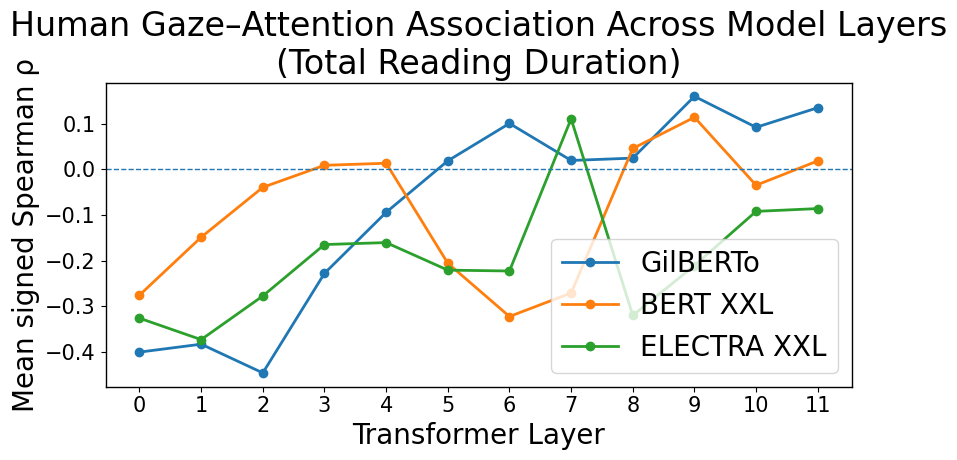

In [ ]:
import matplotlib.pyplot as plt

feature_to_plot = "dur"

plot_df = raw_mean_df[
    raw_mean_df["feature"] == feature_to_plot
]

plt.figure(figsize=(9, 5))

for model_name in ["GilBERTo", "BERT XXL", "ELECTRA XXL"]:
    model_data = (
        plot_df[plot_df["model"] == model_name]
        .sort_values("layer")
    )

    plt.plot(
        model_data["layer"],
        model_data["rho"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.axhline(0, linewidth=1, linestyle="--")

plt.xticks(range(12))
plt.xlabel("Transformer Layer")
plt.ylabel("Mean signed Spearman ρ")
plt.title("Human Gaze–Attention Association Across Model Layers\n(Total Reading Duration)")
plt.legend()
plt.tight_layout()
plt.show()

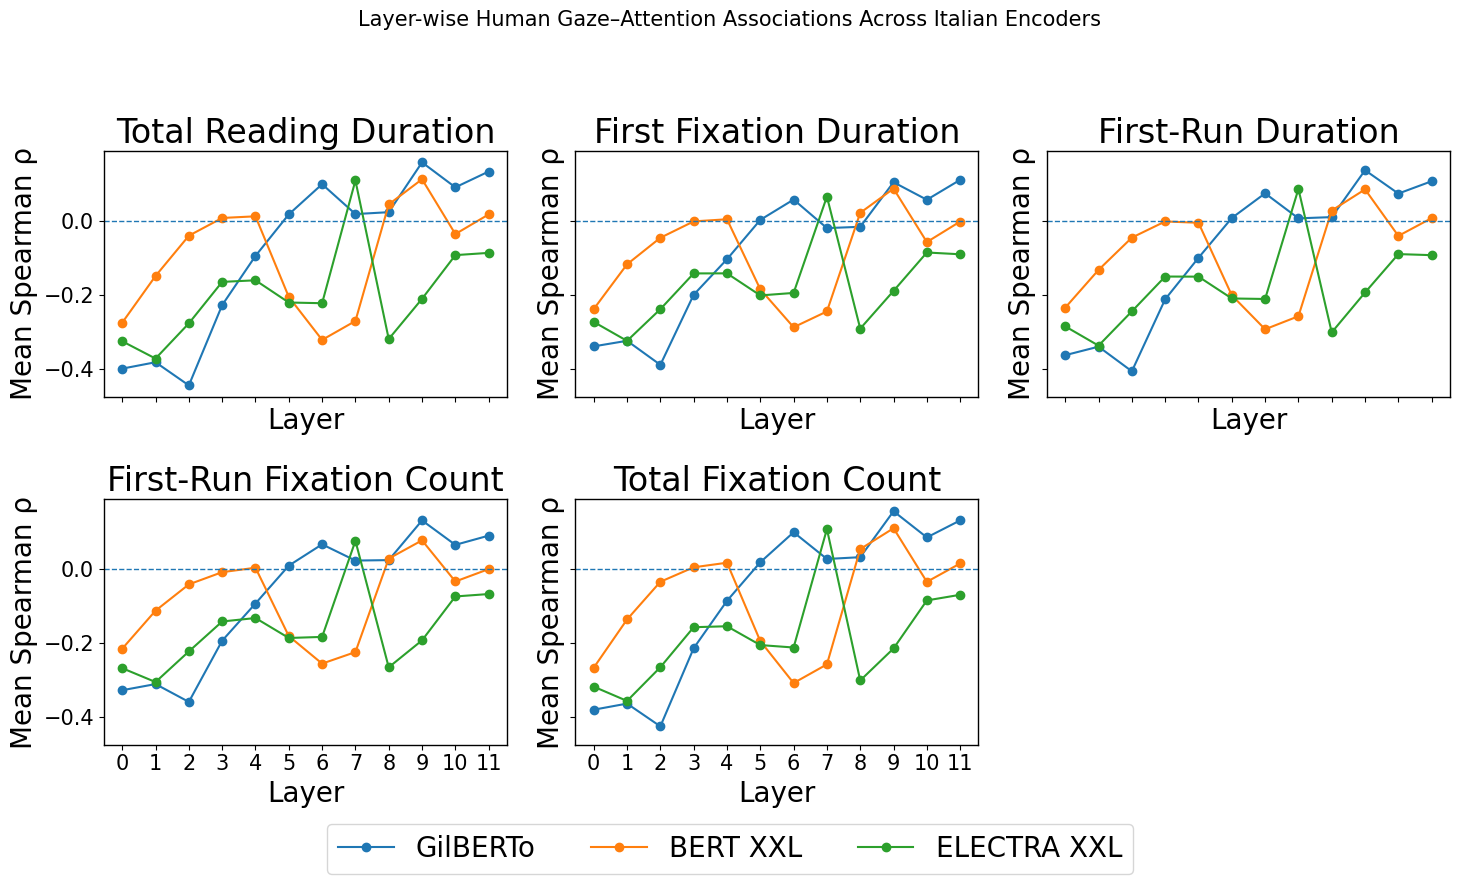

In [ ]:
features_to_plot = [
    ("dur", "Total Reading Duration"),
    ("firstfix_dur", "First Fixation Duration"),
    ("firstrun_dur", "First-Run Duration"),
    ("firstrun_nfix", "First-Run Fixation Count"),
    ("nfix", "Total Fixation Count")
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (feature, title) in zip(axes, features_to_plot):

    feature_df = raw_mean_df[
        raw_mean_df["feature"] == feature
    ]

    for model_name in ["GilBERTo", "BERT XXL", "ELECTRA XXL"]:

        model_data = (
            feature_df[
                feature_df["model"] == model_name
            ]
            .sort_values("layer")
        )

        ax.plot(
            model_data["layer"],
            model_data["rho"],
            marker="o",
            label=model_name
        )

    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_title(title)
    ax.set_xticks(range(12))
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean Spearman ρ")

# Remove unused sixth panel
fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3
)

fig.suptitle(
    "Layer-wise Human Gaze–Attention Associations Across Italian Encoders",
    fontsize=15
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [ ]:
electra_l7_l8 = (
    raw_corr_df[
        (raw_corr_df["model"] == "ELECTRA XXL") &
        (raw_corr_df["feature"] == "dur") &
        (raw_corr_df["layer"].isin([6, 7, 8]))
    ]
    [["participant", "layer", "rho", "pvalue"]]
    .sort_values(["participant", "layer"])
)

display(electra_l7_l8.round(4))

,participant,layer,rho,pvalue
606,1,6,-0.2271,0.0000
607,1,7,0.1375,0.0000
608,1,8,-0.3770,0.0000
666,26,6,-0.2076,0.0000
667,26,7,0.0642,0.0031
668,26,8,-0.2991,0.0000
726,38,6,-0.2264,0.0000
727,38,7,0.1356,0.0000
728,38,8,-0.3284,0.0000
786,43,6,-0.2437,0.0000


In [ ]:
# Correlation between layer-wise profiles of gaze features
# separately for each model

for model_name in ["GilBERTo", "BERT XXL", "ELECTRA XXL"]:

    model_profile = (
        raw_mean_df[
            raw_mean_df["model"] == model_name
        ]
        .pivot(
            index="layer",
            columns="feature",
            values="rho"
        )
    )

    print(f"\n{'='*60}")
    print(model_name)
    print("="*60)

    display(
        model_profile.corr(method="spearman").round(3)
    )


GilBERTo


feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
feature,,,,,
dur,1.000,0.972,0.993,1.000,1.000
firstfix_dur,0.972,1.000,0.986,0.972,0.972
firstrun_dur,0.993,0.986,1.000,0.993,0.993
firstrun_nfix,1.000,0.972,0.993,1.000,1.000
nfix,1.000,0.972,0.993,1.000,1.000



BERT XXL


feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
feature,,,,,
dur,1.000,0.965,0.986,0.986,0.986
firstfix_dur,0.965,1.000,0.965,0.986,0.986
firstrun_dur,0.986,0.965,1.000,0.979,0.965
firstrun_nfix,0.986,0.986,0.979,1.000,0.986
nfix,0.986,0.986,0.965,0.986,1.000



ELECTRA XXL


feature,dur,firstfix_dur,firstrun_dur,firstrun_nfix,nfix
feature,,,,,
dur,1.000,0.979,0.979,0.972,0.979
firstfix_dur,0.979,1.000,0.986,0.965,0.958
firstrun_dur,0.979,0.986,1.000,0.951,0.958
firstrun_nfix,0.972,0.965,0.951,1.000,0.993
nfix,0.979,0.958,0.958,0.993,1.000


In [ ]:
from scipy.stats import spearmanr

model_names = ["GilBERTo", "BERT XXL", "ELECTRA XXL"]

comparison_results = []

for feature in features:

    feature_df = (
        raw_mean_df[
            raw_mean_df["feature"] == feature
        ]
        .pivot(
            index="layer",
            columns="model",
            values="rho"
        )
    )

    pairs = [
        ("GilBERTo", "BERT XXL"),
        ("GilBERTo", "ELECTRA XXL"),
        ("BERT XXL", "ELECTRA XXL")
    ]

    for model_a, model_b in pairs:

        r, p = spearmanr(
            feature_df[model_a],
            feature_df[model_b]
        )

        comparison_results.append({
            "feature": feature,
            "model_a": model_a,
            "model_b": model_b,
            "profile_rho": r,
            "pvalue": p
        })


profile_comparison_df = pd.DataFrame(comparison_results)

display(
    profile_comparison_df.round(4)
)

,feature,model_a,model_b,profile_rho,pvalue
0,dur,GilBERTo,BERT XXL,0.3846,0.2170
1,dur,GilBERTo,ELECTRA XXL,0.4895,0.1063
2,dur,BERT XXL,ELECTRA XXL,0.2308,0.4705
3,firstfix_dur,GilBERTo,BERT XXL,0.1399,0.6646
4,firstfix_dur,GilBERTo,ELECTRA XXL,0.4545,0.1377
5,firstfix_dur,BERT XXL,ELECTRA XXL,-0.0070,0.9828
6,firstrun_dur,GilBERTo,BERT XXL,0.3566,0.2551
7,firstrun_dur,GilBERTo,ELECTRA XXL,0.3846,0.2170
8,firstrun_dur,BERT XXL,ELECTRA XXL,0.0839,0.7954
9,firstrun_nfix,GilBERTo,BERT XXL,0.3077,0.3306
